In [1]:
import torch
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

PATH = str(os.getcwd()) 
__file__ = PATH + '/swag.ipynb'
root_dir = Path(__file__).resolve().parents[2]  # two levels up
sys.path.insert(0, str(root_dir))

import models
from models import baselines
from utils.data_utils import obtain_me_a_nice_sawtooth_dataset_please, obtain_me_a_nice_heaviside_dataset_please, obtain_me_a_nice_gp_dataset_please
from base_networks.base_architectures import Sin, SharpTanh

In [2]:
def build_meta_dataset(num_datasets=10_000, n_range=[40, 100], function_type='sawtooth', x_range=[-4.0, 4.0]):
    md = []
    assert function_type.lower() in ['sawtooth', 'gp', 'heaviside']

    if function_type.lower() == 'sawtooth':
        dataset_func = obtain_me_a_nice_sawtooth_dataset_please
        data_hypers = {'p': 0.75, 'm': 1.33, 'random_linear': True, 'x_range': [-2.0, 2.0]}
    elif function_type.lower() == 'gp':
        dataset_func = obtain_me_a_nice_gp_dataset_please
        data_hypers = {'l': 0.5, 'kernel': 'se', 'x_range': x_range}
    elif function_type.lower() == 'heaviside':
        dataset_func = obtain_me_a_nice_heaviside_dataset_please
        data_hypers = {'x_range': x_range, 'l': 1}

    for _ in range(num_datasets):
        X, y = dataset_func(n_range=n_range, **data_hypers)
        md.append((X, y))
    
    return md

In [3]:
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

hidden_dims = [32, 32]
prior = 'bnn'
model_name = 'swag'
function_type = 'gp'


if prior is None:
    raise ValueError("User failed to specify the prior to use. Total fool.")
saved_models_path = Path(__file__).parent / "saved_models"
if prior != 'bnn':
    file = Path(saved_models_path / prior)
    if not file.is_file():
        raise ValueError("User failed to provide prior name corresponding to valid pretrained BDNP.")

if function_type == 'sawtooth':
    nonlinearity = 'relu'
elif function_type == 'heaviside':
    nonlinearity = 'tanh'
elif function_type == 'gp':
    nonlinearity = 'silu'

if nonlinearity.lower() == 'relu':
    nl = torch.nn.ReLU()
elif nonlinearity.lower() == 'sin':
    nl = Sin()
elif nonlinearity.lower() == 'tanh':
    nl = torch.nn.Tanh()
elif nonlinearity.lower() == 'sigmoid':
    nl = torch.nn.Sigmoid()
elif 'leaky' in nonlinearity.lower():
    nl = torch.nn.LeakyReLU()
elif nonlinearity.lower() == 'swish' or nonlinearity.lower() == 'silu':
    nl = torch.nn.SiLU()
elif nonlinearity.lower() == 'sharptanh':
    nl = SharpTanh()
else:
    raise NotImplementedError("Conversion to torch.nn module not yet implemented for provided nonlinearity string.")

lik = models.GaussianLikelihood(1, sigma_y=0.05)
model_kwargs = {'x_dim': 1,
                'y_dim': 1,
                'likelihood': lik,
                'hidden_dims': hidden_dims,
                'scale_prior': True,
                'nonlinearity': nl}

model_class = baselines.SWAG_BNN

model = model_class(**model_kwargs)

# adopt prior if using pre-trained one.
if prior.lower() != 'bnn':
    pretrained_bdnp = torch.load(PATH + f'/saved_models/{prior}', weights_only=False)
    layerwise_priors = []
    for layer in pretrained_bdnp.layers:
        m = layer.prior.mus.detach()
        if layer.prior_type == 1:
            S = layer.prior.Sigmas.detach()
        elif layer.prior_type == 0:
            S = layer.prior.sigmas.detach().diag_embed()
        else:
            raise ValueError(f"pre-trained BDNP has unsupported type of prior for adoption into {model_name} BNN.")
        layerwise_priors.append((m, S))
    model.adopt_prior(layerwise_priors)

100%|██████████| 2500/2500 [00:03<00:00, 671.96it/s, log_pos=709, log_lik=14.4, log_pri=694] 


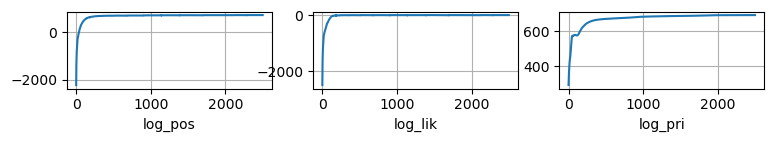

In [8]:
X, y = build_meta_dataset(num_datasets=1, n_range=[10,11], function_type=function_type)[0]
xs = torch.linspace(-4.0, 4.0, 200).unsqueeze(-1)

pretraining_metrics = baselines.pretrain(model,
                                         X,
                                         y,
                                         training_steps=2_500,
                                         learning_rate=1e-2,
)

fig, axes = plt.subplots(1, len(pretraining_metrics), figsize=(3*len(pretraining_metrics), 1))
omitted_steps = 0
for i, (key, value) in enumerate(pretraining_metrics.items()):
    axes[i].plot(value)
    axes[i].set_xlabel(key)
    axes[i].grid()

plt.show()

100%|██████████| 6250/6250 [00:09<00:00, 677.28it/s, log_pos=689, log_lik=3.22, log_pri=686, swa_step=250]  


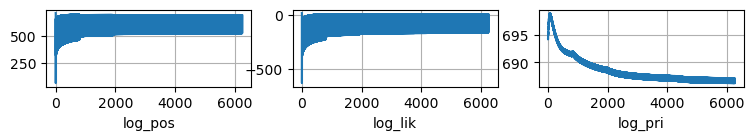

In [9]:
swag_metrics = baselines.run_SWAG(model, X, y, learning_rate=0.01, swa_steps=250, c=25)

fig, axes = plt.subplots(1, len(swag_metrics), figsize=(3*len(swag_metrics), 1))
omitted_steps = 0
for i, (key, value) in enumerate(swag_metrics.items()):
    axes[i].plot(value)
    axes[i].set_xlabel(key)
    axes[i].grid()

plt.show()

In [10]:
with torch.no_grad():
    pred_samps = model.bma_forward(xs, num_samples=50)

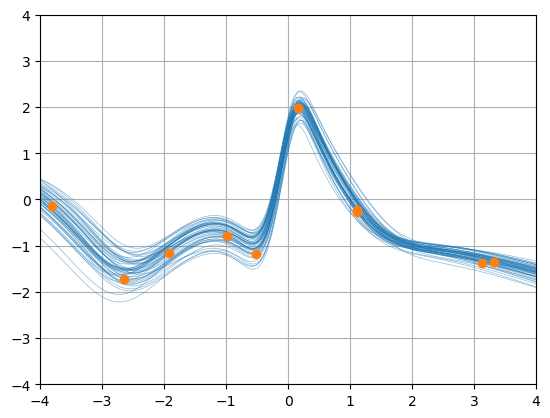

In [11]:
plt.plot(xs.unsqueeze(0).repeat((pred_samps.shape[0], 1, 1)).squeeze(-1).T.cpu(), pred_samps.squeeze(-1).T.cpu(), linewidth=0.5, color='C0', alpha=0.5)
plt.scatter(X, y, color='C1', zorder=10000)
plt.grid()
lim = [-4.0, 4.0]
if function_type.lower() == 'sawtooth':
    lim = [-2.0, 2.0]
plt.xlim(lim)
plt.ylim(lim)
plt.show() 